# Q5) V-Plot

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

input_file = "mapped.bed"

cnts = Counter()

with open(input_file, 'r') as file:
    for line_num, line in enumerate(file):
        fields = line.strip().split('\t')

        start1 = int(fields[2])
        end1 = int(fields[3])
        start2 = int(fields[8])
        end2 = int(fields[9])

        center1 = (start1 + end1) / 2
        center2 = (start2 + end2) / 2

        if line_num < 5:
            print(f"Line {line_num}: c1={center1}, c2={center2}, parts[2]={fields[2]}, parts[3]={fields[3]}, parts[8]={fields[8]}, parts[9]={fields[9]}")

        x = int(center2 - center1)
        y = end2 - start2
        cnts[(x, y)] += 1

Line 0: c1=91428.0, c2=90922.0, parts[2]=90919, parts[3]=91937, parts[8]=90838, parts[9]=91006
Line 1: c1=91428.0, c2=90922.0, parts[2]=90919, parts[3]=91937, parts[8]=90846, parts[9]=90998
Line 2: c1=91428.0, c2=90925.5, parts[2]=90919, parts[3]=91937, parts[8]=90851, parts[9]=91000
Line 3: c1=91428.0, c2=90932.0, parts[2]=90919, parts[3]=91937, parts[8]=90850, parts[9]=91014
Line 4: c1=91428.0, c2=90932.5, parts[2]=90919, parts[3]=91937, parts[8]=90900, parts[9]=90965


### Parsing Paired-End Read Mappings from a BED-like File

We read from a BED-like file (`mapped.bed`) that contains paired-end read mappings. For each line in the file:

1. **Extract Fragment Coordinates**  
   - Parse the line to extract the coordinates of two read fragments: the first and second reads.

2. **Compute Fragment Centers**  
   - Calculate `center1` and `center2` as the midpoints of the first and second fragments, respectively.

3. **Calculate Relative Position and Length**  
   - Compute `x = center2 - center1` — this gives the relative shift between the centers of the two reads.
   - Compute `y = end2 - start2` — the length of the second fragment.

4. **Count Coordinate Pairs**  
   - Use a `Counter` to keep track of how often each `(x, y)` pair appears in the dataset.

5. **Debug Output**  
   - The condition `line_num < 5` prints the first few parsed lines for debugging or previewing purposes.

This processing helps in visualizing how fragment lengths and relative positions cluster around protein binding sites.


In [7]:
print(f"Total unique (X, Y) pairs: {len(cnts)}")

x_vals = sorted({coord[0] for coord in cnts})
y_vals = sorted({coord[1] for coord in cnts})

x_ind = {val: idx for idx, val in enumerate(x_vals)}
y_ind = {val: idx for idx, val in enumerate(y_vals)}

Total unique (X, Y) pairs: 275862


### Preparing Heatmap Axes from (x, y) Pairs

After collecting all `(x, y)` coordinate pairs:

- **Extract and sort unique values**:  
  All unique `x`-values (position offsets) and `y`-values (fragment lengths) are extracted and sorted.

- **Create index mappings**:  
  We build two dictionaries:  
  - `x_ind`: maps each unique `x` to its column index in the matrix.  
  - `y_ind`: maps each unique `y` to its row index in the matrix.

These mappings are essential for converting real-world coordinate pairs into proper indices in the 2D matrix used for heatmap generation.


In [8]:
matrix = np.zeros((len(y_vals), len(x_vals)))

for (x, y), z in cnts.items():
    row = y_ind[y]
    col = x_ind[x]
    matrix[row, col] = z

### Constructing a 2D Matrix for Heatmap Visualization

We create a 2D matrix where:

- **Rows correspond to fragment lengths (`y`)**  
  Each row represents a unique observed fragment length.

- **Columns correspond to position offsets (`x`)**  
  Each column represents a unique relative offset between fragment centers.

- **Matrix Values (`z`)**  
  The value at `matrix[row][col]` indicates how many times the `(x, y)` pair was observed in the dataset.

This matrix serves as the basis for generating a heatmap that visualizes the clustering of fragment positions and lengths around specific genomic features.


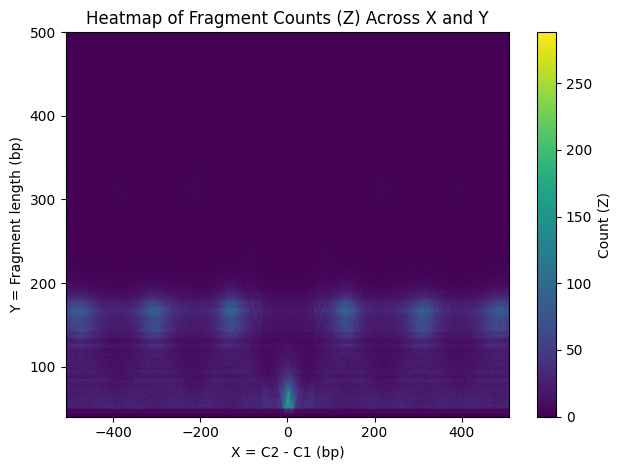

In [9]:
fig, ax = plt.subplots()
heatmap = ax.imshow(
    matrix,
    aspect='auto',
    origin='lower',
    extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)]
)

ax.set_xlabel("X = C2 - C1 (bp)")
ax.set_ylabel("Y = Fragment length (bp)")
ax.set_title("Heatmap of Fragment Counts (Z) Across X and Y")

fig.colorbar(heatmap, label="Count (Z)")

plt.tight_layout()
plt.show()


We plot a heatmap to visualize the fragment distribution:

The X-axis shows the offset between fragment centers (C2 - C1), which reflects symmetry around binding sites.

The Y-axis shows fragment lengths.

Color intensity (Z-value) indicates how often that (X, Y) pair occurs.

This results in a V-shaped pattern.